In [53]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [21]:
bgose_id = "041"

ds_T = xr.open_dataset(
    f"/work/Katherine.Turner/BGOSE/data_i{bgose_id}_glob/Theta_bgoseI{bgose_id}s65_2013to2026_monthly.nc"
)
ds_S = xr.open_dataset(
    f"/work/Katherine.Turner/BGOSE/data_i{bgose_id}_glob/Salt_bgoseI{bgose_id}s65_2013to2026_monthly.nc"
)

In [29]:
theta_nans = ds_T.THETA.where(ds_T.THETA != 0)
theta_top = theta_nans.bfill("Z", limit=None)[:, 0, :, :]

theta_draft = theta_top - ds_T.THETA[:, 0, :, :]
theta_draft = theta_draft.where(theta_draft != 0)

In [41]:
salt_nans = ds_S.SALT.where(ds_S.SALT != 0)
salt_top = salt_nans.bfill("Z", limit=None)[:, 0, :, :]

salt_draft = salt_top - ds_S.SALT[:, 0, :, :]
salt_draft = salt_draft.where(salt_draft != 0)

In [42]:
valid_water = ds_T.THETA != 0
first_valid_k = valid_water.argmax(dim="Z")
is_ice_shelf_interface = (first_valid_k > 0) & valid_water.any(dim="Z")
interface_k = first_valid_k.where(is_ice_shelf_interface)

In [47]:
ds_out = xr.Dataset(
    data_vars=dict(
        theta_draft=(["time", "YC", "XC"], theta_draft.data),
        salt_draft=(["time", "YC", "XC"], salt_draft.data),
        interface_idx=(["time", "YC", "XC"], interface_k.data),
    ),
    coords=dict(
        time=ds_T.time.data,
        XC=ds_T.XC.data,
        YC=ds_T.YC.data,
    ),
)

ds_out.to_netcdf("/work/Katherine.Turner/BGOSE/data_i041_glob/ice_draft_TS.nc")

## Look at fields in T/S space and separate by region

In [55]:
ds = xr.open_dataset("/work/Katherine.Turner/BGOSE/data_i041_glob/ice_draft_TS.nc")
ds_BGOSE = xr.open_dataset("data_i000_SO65/iceshelves_bgose6_extended.nc")

In [72]:
idx = {
    "AP": ds_BGOSE.shelf_mask.isin(np.arange(1, 12)),
    "WA": ds_BGOSE.shelf_mask.isin(np.arange(13, 27)),
    "RS": ds_BGOSE.shelf_mask.isin(np.arange(27, 29)),
    "EA": ds_BGOSE.shelf_mask.isin(np.arange(29, 66)),
    "RF": ds_BGOSE.shelf_mask.isin([12, 66]),
    "other": ds_BGOSE.shelf_mask == 0,
}

In [62]:
theta_mean = ds.theta_draft[24:, :, :].mean(dim="time")
salt_mean = ds.salt_draft[24:, :, :].mean(dim="time")

In [87]:
ds_T.Z.values

array([-2.100e+00, -6.700e+00, -1.215e+01, -1.855e+01, -2.625e+01,
       -3.525e+01, -4.500e+01, -5.500e+01, -6.500e+01, -7.500e+01,
       -8.500e+01, -9.500e+01, -1.050e+02, -1.150e+02, -1.250e+02,
       -1.350e+02, -1.465e+02, -1.615e+02, -1.800e+02, -2.000e+02,
       -2.200e+02, -2.400e+02, -2.600e+02, -2.800e+02, -3.010e+02,
       -3.270e+02, -3.610e+02, -4.025e+02, -4.500e+02, -5.000e+02,
       -5.515e+02, -6.140e+02, -7.000e+02, -8.000e+02, -9.000e+02,
       -1.000e+03, -1.100e+03, -1.225e+03, -1.400e+03, -1.600e+03,
       -1.800e+03, -2.010e+03, -2.270e+03, -2.610e+03, -3.000e+03,
       -3.400e+03, -3.800e+03, -4.200e+03, -4.600e+03, -5.000e+03,
       -5.400e+03, -5.800e+03], dtype=float32)

In [83]:
ds.interface_idx.shape
theta_mean.shape

(285, 2160)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


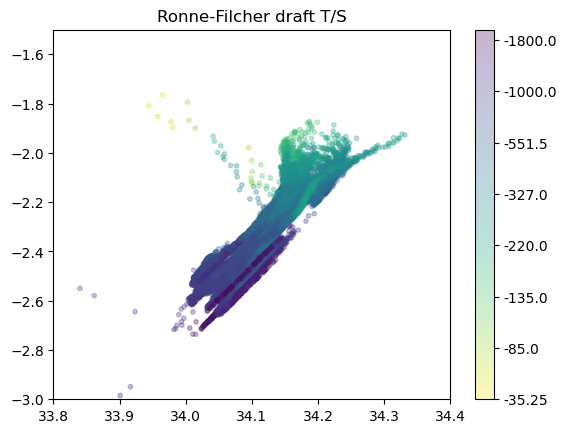

In [108]:
for x in ['RF']:#, 'EA', 'RS']:
    T = (theta_mean * idx[x]).values.flatten()
    S = (salt_mean * idx[x]).values.flatten()
    
    k = ds.interface_idx[0,:,:].values.flatten()

    mask = ~np.isnan(T) & ~np.isnan(S)
    T_vals = T[mask]
    S_vals = S[mask]
    k = k[mask]

    plt.scatter(S_vals, T_vals, c=k, s=10, alpha=0.3, label=x, cmap='viridis_r')

plt.xlim([33.8, 34.4])
plt.ylim([-3, -1.5])
#plt.legend()

cbar = plt.colorbar()
cbar.set_ticks(np.arange(5,45,5))
cbar.set_ticklabels(ds_T.Z[5:45:5].values)

plt.title('Ronne-Filcher draft T/S')
plt.savefig(f'/work/Katherine.Turner/BGOSE/figures/TS_draft_{x}.png', format='png')
plt.savefig(f'/work/Katherine.Turner/BGOSE/figures/TS_draft_{x}.eps', format='eps')